<a href="https://colab.research.google.com/github/shecodespsy/SheCodesPsy-2026/blob/main/S3-data-analysis/Analyzing_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analyzing Data**

In [1]:
!git clone https://github.com/shecodespsy/SheCodesPsy-2026.git

Cloning into 'SheCodesPsy-2026'...
remote: Enumerating objects: 196, done.
remote: Counting objects: 100% (196/196), done.
remote: Compressing objects: 100% (185/185), done.
remote: Total 196 (delta 106), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (196/196), 1.44 MiB | 8.01 MiB/s, done.
Resolving deltas: 100% (106/106), done.


## Import libraries

In [2]:
# libraries for scientific computing
import numpy as np

# libraries for data manipulation and analysis
import pandas as pd

# libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

# libraries for statistics
from scipy.stats import pearsonr, ttest_ind, f_oneway, shapiro, levene

# **Experimental dataset**

We will now load a CSV dataset containing simulated psychological data.

**<font color="teal">The dataset is synthetic and simulates a simple psychology experiment:</font>** <br>the data were generated for teaching purposes and do not come from real participants. <br>

## <font color="orange">**Behavioral task** </font>

This is a psychology experiment with <u><font color="orange">40 participants</font></u> divided into a `control group` and a `clinical group`.<br>
Each participant completed a behavioral task under different experimental conditions (`neutral`, `social_evaluation`, or `time_pressure`) and provided **<u>questionnaire-like measures</u>** such as **anxiety**, **depression**, **perceived stress** scores, and **sleep hours**. <br>The dataset also includes **<u>task performance</u>** measures such as **accuracy** and **reaction time**.

We will use this dataset to practice:
1. data inspection
2. data filtering/cleaning
3. computing descriptive statistics: mean, variance, frequency
4. computing correlations
5. t-tests
6. ANOVA
7. data visualization/plotting.

## Load the dataset

In [3]:
# Load the dataset with pandas (pd)
data = pd.read_csv("SheCodesPsy-2026/Data_analysis/psyexp_synthetic_data.csv")

## Dataset inspection

### RECAP from previous lesson

- <font size="3">`data.head()` : show first rows
- <font size="3">`data.shape` : number of rows and columns
- <font size="3">`data.columns` : column names
- <font size="3">`data.info()` : shows variable types and missing values</font><br>
- <font size="3">`data.isna().sum()` :  Missing values per column

- <font size="3">`data.describe()` : summarizes the numerical variables</font><br>
- <font size="3">`data.describe(include="object")` : summarizes the cathegorical variables</font>




In [35]:
# Print the "head" the dataset: just the first few rows
# Each row correspond to a participant

data.head()

,participant_id,age,gender,group,condition,anxiety_score,depression_score,perceived_stress,sleep_hours,accuracy,reaction_time_ms
0,P001,22,woman,control,neutral,34.8,29.3,35.2,5.9,0.99,383
1,P002,24,woman,control,social_evaluation,37.6,36.4,32.0,6.7,0.83,560
2,P003,23,man,control,time_pressure,45.2,45.2,33.2,6.3,0.93,595
3,P004,29,woman,control,neutral,38.6,31.6,33.2,5.7,0.80,568
4,P005,18,woman,control,social_evaluation,31.8,15.0,22.4,5.6,0.84,514


### **Size of the dataset**

<font size="3">We can count how many partecipants (**rows**) are in the dataset and how many variables we have per partecipant (**columns**).</font>

In [38]:
# Print the shape of the dataset : (40, 11) = (n_rows, n_columns)
print(f'\nSize of the dataset :\n\n (n. participants, n.variables) = {data.shape}\n')



Size of the dataset :

 (n. participants, n.variables) = (40, 11)



In [39]:
n_participants, n_variables = data.shape
print("\n\nNumber of participants:", n_participants)
print("Number of variables:", n_variables,'\n')




Number of participants: 40
Number of variables: 11 



In [41]:
# Dataset info: variable types and missing values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   participant_id    40 non-null     object 
 1   age               40 non-null     int64  
 2   gender            40 non-null     object 
 3   group             40 non-null     object 
 4   condition         40 non-null     object 
 5   anxiety_score     40 non-null     float64
 6   depression_score  39 non-null     float64
 7   perceived_stress  40 non-null     float64
 8   sleep_hours       39 non-null     float64
 9   accuracy          39 non-null     float64
 10  reaction_time_ms  40 non-null     int64  
dtypes: float64(5), int64(2), object(4)
memory usage: 3.6+ KB


### **Columns** of the dataset: variables

In [42]:
# print the names of the variables in the dataset.
data.columns

Index(['participant_id', 'age', 'gender', 'group', 'condition',
       'anxiety_score', 'depression_score', 'perceived_stress', 'sleep_hours',
       'accuracy', 'reaction_time_ms'],
      dtype='object')

In [43]:
print('\n',print( data.columns.tolist() ))

['participant_id', 'age', 'gender', 'group', 'condition', 'anxiety_score', 'depression_score', 'perceived_stress', 'sleep_hours', 'accuracy', 'reaction_time_ms']

 None


In [45]:
# Access a column using its name
# data['age']
data['age'].head()

,age
0,22
1,24
2,23
3,29
4,18


In [49]:
# You can perform operations on the columns in the dataset.
# EXAMPLE: average

age = data['age'] # store the average in an array
print('Average age of participants', age.mean())

Average age of participants 22.6


✏️ **It's your turn!**

Let's practice loading and inspecting data.
Use the code cell below following the instructions within the comments. Try to write the code yourself to achieve the described results

In [ ]:
# EXCERCISE 1:
# 1) Store the values of the reaction time column in an array named ‘RT’.
# 2) Compute and print the minimum and maximum reaction times in the dataset.


### **Rows** of the dataset

We know that `data.head()` is the commant to print the first rows of the dataset.

In [50]:
# REMINDER
# data.head() is the commant to print the first rows of the dataset
data.head()

,participant_id,age,gender,group,condition,anxiety_score,depression_score,perceived_stress,sleep_hours,accuracy,reaction_time_ms
0,P001,22,woman,control,neutral,34.8,29.3,35.2,5.9,0.99,383
1,P002,24,woman,control,social_evaluation,37.6,36.4,32.0,6.7,0.83,560
2,P003,23,man,control,time_pressure,45.2,45.2,33.2,6.3,0.93,595
3,P004,29,woman,control,neutral,38.6,31.6,33.2,5.7,0.80,568
4,P005,18,woman,control,social_evaluation,31.8,15.0,22.4,5.6,0.84,514


but there may be cases where we want to display specific rows.
<br>

`data.iloc[ <row index> ]` displays specific rows of the dataset

<br>
<u>Example:</u> <br>

command to display the `11th` row: `data.iloc[10]`<br><br>

<b>Reminder:</b> in python the <b>ENUMERATION</b> starts from <b>0</b>! Thus:
- if you want to print the `first raw`, you should use the index `0`
- if you want to print the `second raw`,  you should use the index `1`

<br>

In [53]:
# Sometimes we would like to display specific rows
data.iloc[2]

,2
participant_id,P003
age,23
gender,man
group,control
condition,time_pressure
anxiety_score,45.2
depression_score,45.2
perceived_stress,33.2
sleep_hours,6.3
accuracy,0.93


If you need to print more than one row, the command:

`data.iloc[ list of row indexes ]`  

displays a specific list of rows of the dataset

There are two common cases:

1) Use a slice when the rows are consecutive: `data.iloc[start_index:stop_index]`


In [67]:
# Example: display line from 2 to 7
# Note: the second number is excluded, so 2:7 means: [ 2, 3, 4, 5, 6 ]
data.iloc[2:7]

,participant_id,age,gender,group,condition,anxiety_score,depression_score,perceived_stress,sleep_hours,accuracy,reaction_time_ms
2,P003,23,man,control,time_pressure,45.2,45.2,33.2,6.3,0.93,595
3,P004,29,woman,control,neutral,38.6,31.6,33.2,5.7,0.80,568
4,P005,18,woman,control,social_evaluation,31.8,15.0,22.4,5.6,0.84,514
5,P006,20,woman,control,time_pressure,36.8,33.8,31.4,6.9,0.80,709
6,P007,20,woman,control,neutral,31.0,NaN,28.9,7.8,0.91,483


2) Use a list when you want to choose specific rows manually: `data.iloc[ [index1, index2, index3] ]`

In [58]:
# print a selected list of rows
data.iloc[[2,3,5,10]]

,participant_id,age,gender,group,condition,anxiety_score,depression_score,perceived_stress,sleep_hours,accuracy,reaction_time_ms
2,P003,23,man,control,time_pressure,45.2,45.2,33.2,6.3,0.93,595
3,P004,29,woman,control,neutral,38.6,31.6,33.2,5.7,0.80,568
5,P006,20,woman,control,time_pressure,36.8,33.8,31.4,6.9,0.80,709
10,P011,20,woman,control,social_evaluation,33.9,31.9,23.6,7.2,0.64,870


In [59]:
# print a selected list of rows
list_idxs = [2,3,5,10]
data.iloc[list_idxs]

,participant_id,age,gender,group,condition,anxiety_score,depression_score,perceived_stress,sleep_hours,accuracy,reaction_time_ms
2,P003,23,man,control,time_pressure,45.2,45.2,33.2,6.3,0.93,595
3,P004,29,woman,control,neutral,38.6,31.6,33.2,5.7,0.80,568
5,P006,20,woman,control,time_pressure,36.8,33.8,31.4,6.9,0.80,709
10,P011,20,woman,control,social_evaluation,33.9,31.9,23.6,7.2,0.64,870


In [65]:
# EXTRA: with the same logic we can display selected rows and columns
# data.iloc[ row_idxs, column_idxs ]

data.iloc[20:25, 2:5]

,gender,group,condition
20,woman,clinical,time_pressure
21,woman,clinical,neutral
22,woman,clinical,social_evaluation
23,woman,clinical,time_pressure
24,woman,clinical,neutral


✏️ **It's your turn!**

Let's practice inspecting data.
Use the code cell below following the instructions within the comments. Try to write the code yourself to achieve the described results

In [49]:
# EXERCISE 1:
#

In [49]:
# basic statistics with numerical variables
data.describe()

In [ ]:
data.describe(include="object")

,participant_id,gender,group,condition
count,40,40,40,40
unique,40,3,2,3
top,P001,woman,control,neutral
freq,1,34,20,14


### **Variables, Data Types, and Measurement Scales**

Descriptive statistics begins with a deep understanding of the data we are analyzing. <br>
The classification of a variable determines which type of statistical analysis is valid.

### <font color="orange">Types of Variables: Quantitative vs. Qualitative</font>


<font size="3">Data are fundamentally classified into two categories:</font>


#### 1. Quantitative / Numerical:

These represent quantities, are inherently numerical, and can be measured.
        
- **Discrete**: Take countable values, usually integers, and values between two adjacent points are not meaningful (e.g., number of children, number of ad clicks, number of complaints).

- **Continuous**: Take any value within a given range (e.g., height, weight, temperature, salary, response time).


#### 2. Qualitative / Categorical:

These represent qualities, attributes, or labels.

- **Nominal**: Categories without order or hierarchy (e.g., eye color, country of origin, marital status).

- **Ordinal**: Categories with an implicit order or hierarchy, but the distances between categories are not necessarily equal (e.g., satisfaction level: Low, Medium, High; clothing sizes: S, M, L).


In [ ]:
print('\n\nVariable type:\n')
print(display(data.dtypes))



Variable type:



,0
participant_id,object
age,int64
gender,object
group,object
condition,object
anxiety_score,float64
depression_score,float64
perceived_stress,float64
sleep_hours,float64
accuracy,float64


None


`data.select_dtypes(include='number')` select the dataset columns correspondent to numerical values
`data.select_dtypes(include='object')` select the dataset columns correspondent to categorical values

In [ ]:
# Print ONLY the numerical variables of the dataset
data.select_dtypes(include='number').head()

,age,anxiety_score,depression_score,perceived_stress,sleep_hours,accuracy,reaction_time_ms
0,22,34.8,29.3,35.2,5.9,0.99,383
1,24,37.6,36.4,32.0,6.7,0.83,560
2,23,45.2,45.2,33.2,6.3,0.93,595
3,29,38.6,31.6,33.2,5.7,0.80,568
4,18,31.8,15.0,22.4,5.6,0.84,514


In [ ]:
# Let's store two lists, containing respectively
#  - the numerical variables
#  - the categorical variables
# in the dataset

numerical_variables   = data.select_dtypes(include="number").columns.tolist()
categorical_variables = data.select_dtypes(exclude="number").columns.tolist()

print("Numerical variables:", numerical_variables)
print("Categorical variables:", categorical_variables)



Numerical variables: ['age', 'anxiety_score', 'depression_score', 'perceived_stress', 'sleep_hours', 'accuracy', 'reaction_time_ms']
Categorical variables: ['participant_id', 'gender', 'group', 'condition']


In [ ]:
data[['age', 'anxiety_score']].head()

,age,anxiety_score
0,22,34.8
1,24,37.6
2,23,45.2
3,29,38.6
4,18,31.8


In [ ]:
# Print ONLY the numerical variables of the dataset, using numerical_variables
display(data[numerical_variables].head())


,age,anxiety_score,depression_score,perceived_stress,sleep_hours,accuracy,reaction_time_ms
0,22,34.8,29.3,35.2,5.9,0.99,383
1,24,37.6,36.4,32.0,6.7,0.83,560
2,23,45.2,45.2,33.2,6.3,0.93,595
3,29,38.6,31.6,33.2,5.7,0.80,568
4,18,31.8,15.0,22.4,5.6,0.84,514


In [ ]:
# Print ONLY the categorical variables of the dataset
display(data[categorical_variables].head())

,participant_id,gender,group,condition
0,P001,woman,control,neutral
1,P002,woman,control,social_evaluation
2,P003,man,control,time_pressure
3,P004,woman,control,neutral
4,P005,woman,control,social_evaluation


### Attributes of categorical variables

`value_counts()` counts the features of a specific categorical variable

In [ ]:
data["gender"].value_counts()

,count
gender,
woman,34
man,5
non_binary,1


In [ ]:
data["group"].value_counts() # EXC

,count
group,
control,20
clinical,20


In [ ]:
data["condition"].value_counts() # EXC

,count
condition,
neutral,14
social_evaluation,13
time_pressure,13


# <font color="orange">**Filtering and cleaning data**</font>

### **Check missing values**

<font size="3">Missing values are common in psychological datasets. For example, a participant may:</font>
- <font size="3">skip a questionnaire item,</font>
- <font size="3">fail to complete a task,</font>
- <font size="3">produce unusable behavioral data,</font>
- <font size="3">...</font>

In [ ]:
# Print which rows contain at least a Nan value:
data[data.isna().any(axis=1)]

,participant_id,age,gender,group,condition,anxiety_score,depression_score,perceived_stress,sleep_hours,accuracy,reaction_time_ms
6,P007,20,woman,control,neutral,31.0,NaN,28.9,7.8,0.91,483
14,P015,20,man,control,time_pressure,36.0,31.9,24.7,NaN,0.91,581
35,P036,19,woman,clinical,time_pressure,49.8,33.9,24.6,6.6,NaN,714


In [ ]:
# List how many Nan values are stored in each variable/column
display(data.isna().sum())

,0
participant_id,0
age,0
gender,0
group,0
condition,0
anxiety_score,0
depression_score,1
perceived_stress,0
sleep_hours,1
accuracy,1


### **Remove rows with missing values**

<font size="3">The best practice is **removing rows with missing values in variables needed for analysis**.
<br>We store the filtered data in another dataset named "data_clean"
</font>

In [ ]:
data_clean_1 = data.dropna()

In [ ]:
# Print the size of the cleaned dataset
print(f'\nSize of the dataset after removing rows with missing values:\n\n (n. participants, n.variables) = {data_clean_1.shape}\n')


Size of the dataset after removing rows with missing values:

 (n. participants, n.variables) = (37, 11)



### **Remove implausible numerical values**

Another important cleaning step is checking whether numerical values fall within a plausible range.

For example, in reaction-time data, extremely small or extremely large values may not reflect a real cognitive response. Very fast responses can indicate accidental key presses, while very slow responses can indicate distraction, hesitation, or technical problems.

In this example, we keep only reaction times between **200 ms** and **1500 ms**:

- values below 200 ms are usually too fast to reflect a meaningful response;
- values above 1500 ms may reflect delayed or inattentive responses.

These thresholds should always be chosen based on
- the task,
- the population,
- the research question.

In [ ]:
# We restrict the rows to the ones having valid reaction-time
data_clean = data_clean_1[ (data_clean_1["reaction_time_ms"] >= 200) & (data_clean_1["reaction_time_ms"] <= 1500) ]

In [ ]:
# Print the size of the cleaned dataset
print(f'\nSize of the dataset after removing rows with non-valid reaction-times:\n\n (n. participants, n.variables) = {data_clean.shape}\n')


Size of the dataset after removing rows with non-valid reaction-times:

 (n. participants, n.variables) = (35, 11)



- <font size="3">This is the summary of the dataset **before** data cleaning:</font>


In [ ]:
data.describe()

,age,anxiety_score,depression_score,perceived_stress,sleep_hours,accuracy,reaction_time_ms
count,40.00000,40.000000,39.000000,40.000000,39.000000,39.000000,40.000000
mean,22.60000,46.475000,37.092308,32.805000,6.517949,0.839487,638.400000
std,3.03653,12.675046,10.501839,7.193514,0.782665,0.083727,230.902333
min,18.00000,25.900000,15.000000,19.100000,4.400000,0.640000,180.000000
25%,20.00000,36.300000,30.750000,26.925000,6.050000,0.795000,566.000000
50%,22.00000,42.650000,35.700000,33.200000,6.600000,0.840000,629.500000
75%,25.00000,57.400000,44.900000,37.025000,6.900000,0.900000,697.000000
max,29.00000,72.100000,56.800000,51.000000,9.000000,0.990000,1850.000000


- <font size="3">This is the summary of the dataset **after** data cleaning:</font>


In [ ]:
data_clean.describe()

,age,anxiety_score,depression_score,perceived_stress,sleep_hours,accuracy,reaction_time_ms
count,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,22.714286,46.705714,37.177143,32.922857,6.502857,0.836857,620.800000
std,3.073333,12.998415,10.936853,7.148183,0.766768,0.075489,102.500158
min,18.000000,25.900000,15.000000,19.100000,4.400000,0.640000,383.000000
25%,20.000000,36.600000,29.650000,27.250000,6.050000,0.795000,570.000000
50%,22.000000,41.700000,36.200000,33.200000,6.500000,0.840000,630.000000
75%,25.500000,57.500000,44.900000,36.350000,6.900000,0.885000,689.500000
max,29.000000,72.100000,56.800000,51.000000,9.000000,0.990000,870.000000


### Save cleaned data

In [ ]:
data_clean.to_csv("psychology_experiment_clean_data.csv", index=False)

# **Computing descriptive statistics**


## Measures of Central Tendency and Dispersion

When working with large datasets, it is impossible to inspect every value. Descriptive measures allow us to summarize the distribution of the data in one or two key numbers.

### <font color="orange">Measures of Central Tendency (Position)</font>

These measures look for the value that best represents the **center of the data distribution**.

#### 1. The Arithmetic Mean ($\bar{x}$)

It is the <font color="orange">**average**</font> of a dataset. It is the best-known measure, but it is highly sensitive to **outliers**.

$$
\bar{x} = \frac{\sum_{i=1}^{n} x_i}{n}
$$

**Ideal Use:** **Quantitative** data (Interval or Ratio) with a symmetric distribution or without outliers.

#### 2. The Median (Me)

It is the **central value** that divides the ordered dataset exactly in half (the 50th percentile). Fifty percent of the observations are below the median and fifty percent are above it.

**Ideal Use:** **Quantitative** or **Ordinal** data. It is the best option when there are **outliers**, because it is robust to them and is not pulled by extreme values.

#### 3. The Mode (Mo)

It is the **value or category that occurs most frequently** in a dataset.

**Ideal Use:** The only suitable measure of central tendency for **Nominal Qualitative** data. It is also used for discrete quantitative data or to identify peaks in distributions.


In [ ]:
# show reaction-time (cleaned data only)
data_clean.get('reaction_time_ms')

,reaction_time_ms
0,383
1,560
2,595
3,568
4,514
5,709
7,508
8,711
9,520
10,870


In [ ]:
# 1. Mean
mean_RT = data_clean['reaction_time_ms'].mean()
print(f"Mean (including outliers): {mean_RT:.2f} ms")


Mean (including outliers): 620.80 ms


In [ ]:
# 2. Median
median_RT = data_clean['reaction_time_ms'].median()
print(f"Median: {median_RT:.2f} ms")


Median: 630.00 ms


In [ ]:
# 3. Mode
age_mode = data_clean["age"].mode()
print(f"The mode of Age is: {age_mode}")


The mode of Age is: 0    20
Name: age, dtype: int64


## <font color="orange">Measures of Dispersion (Variability)</font>

These measures indicate **how spread out** the data are around the center. Low dispersion indicates that values are tightly grouped, suggesting consistency.

#### 1. Range and Interquartile Range (IQR)

- **<u>Range:</u>** Is the difference between the maximum and minimum value of a set of data.<br> It is **<font color="orange">extremely </font>sensitive to outliers**.
- **<u>Interquartile Range (IQR):</u>** Is the difference between the **third quartile** ($Q_3$, 75% of the data) and the **first quartile** ($Q_1$, 25% of the data). <br>The IQR describes the range of the **central 50%** of the data and is **robust to outliers**.

$$
	\text{IQR} = Q_3 - Q_1
$$

#### 2. Variance ($\sigma^2$) and Standard Deviation ($\sigma$)

* **<u>Variance:</u>** The average of the squared differences between each value and the mean. <br>Squaring removes the effect of negative signs in deviations.

$$
\text{Variance: } \;\;\;\;\; Var(x) = \frac{\sum (x_i - \bar{x})^2}{n-1}
$$

* **<u>Standard Deviation ($\sigma$):</u>** The **square root of the variance**. <br>This brings the measure back to the **same units** as the original data, making interpretation easier.

$$
	\text{Standard Deviation: } \;\;\;\;\; \sigma = \sqrt{\frac{\sum (x_i - \bar{x})^2}{n-1}}
$$

 **Interpretation:** A large standard deviation means that data points are, on average, far from the mean.

#### 3. Coefficient of Variation (CV)

The CV is a measure of **<u>relative dispersion</u>**. It is calculated by dividing the standard deviation by the mean.

$$
	\text{CV} = \frac{\sigma}{\bar{x}} 	\times 100
$$

**Ideal Use:** Comparing dispersion between two datasets that have **very different units or means** (e.g., variability in height vs. variability in weight). A higher CV indicates greater relative variability.


In [ ]:
# 1. Range
range_RT = data_clean['reaction_time_ms'].max() - data_clean['reaction_time_ms'].min()
print(f"Reaction-time range: {range_RT:.2f} ms")

# IQR: Interquartile Range
q1  = data_clean['reaction_time_ms'].quantile(0.25)
q3  = data_clean['reaction_time_ms'].quantile(0.75)
iqr = q3 - q1
print(f"\nReaction-time IQR: {iqr:.2f} ms\n")

Reaction-time range: 487.00 ms

Reaction-time IQR: 119.50 ms



In [ ]:
# 2. Variance and standard deviation

# Variance
variance = data_clean['reaction_time_ms'].var()
print(f"\nReaction-time variance: {variance:.2f}")

# Standard deviation
std = data_clean['reaction_time_ms'].std()
print(f"\nReaction-time standard deviation: {std:.2f} ms")



Reaction-time variance: 10506.28

Reaction-time standard deviation: 102.50 ms


## **Frequency Distributions and Visualization**

### **<font color="orange">Create a frequency table for reaction times</font>**

After cleaning the reaction-time values, we can summarize their distribution using a frequency table.

Reaction time is a continuous numerical variable, so we first divide its range into intervals, called **bins**. Then, for each bin, we count how many observations fall inside that interval.

This table helps us understand the shape of the reaction-time distribution before plotting it as a histogram.

The table includes:

- **Absolute frequency**: the number of observations in each bin;
- **Relative frequency**: the proportion of observations in each bin;
- **Cumulative frequency**: the number of observations up to that bin;
- **Cumulative relative frequency**: the proportion of observations up to that bin.

This is the same logic behind a histogram: bins on the x-axis, frequencies on the y-axis.

In [ ]:
plt.subplots()
sns.histplot(data=data_clean, x="reaction_time_ms", bins=21)

plt.xlabel("Reaction time (ms)")
plt.ylabel("Frequency")
plt.title("Distribution of cleaned reaction times")


Bonus

In [ ]:
# Data after restricting the reaction-time range
rt_clean = pd.DataFrame({"RT": data_clean["reaction_time_ms"]})

print(f"Size of the reaction-time array: {len(rt_clean)}")

Size of the reaction-time array: 35


In [ ]:
# Create a frequency table for reaction times

# 1. Define the number of bins
num_bins = 21

# 2. Create equally spaced bin edges between the minimum and maximum reaction time
rt_bins = np.linspace(rt_clean["RT"].min(), rt_clean["RT"].max(), num_bins + 1)

# 3. Create readable labels for each bin
bin_labels = [f"{start:.0f}-{end:.0f}" for start, end in zip(rt_bins[:-1], rt_bins[1:])]

# 4. Assign each reaction-time value to one bin
rt_clean["Bins"] = pd.cut(rt_clean["RT"], bins=rt_bins, include_lowest=True, right=True, labels=bin_labels)

rt_clean.head()

,RT,Bins
0,383,383-406
1,560,545-569
2,595,592-615
3,568,545-569
4,514,499-522


In [ ]:
# Calculate frequencies

absolute_frequency = rt_clean["Bins"].value_counts().sort_index()
total_observations = absolute_frequency.sum()

relative_frequency = absolute_frequency / total_observations
cumulative_frequency = absolute_frequency.cumsum()
cumulative_relative_frequency = relative_frequency.cumsum()

In [ ]:
# Create the frequency table

distribution_df = pd.DataFrame({"Absolute Frequency": absolute_frequency,
                                "Relative Frequency": relative_frequency.map("{:.2%}".format),
                                "Cumulative Frequency": cumulative_frequency,
                                "Cumulative Relative Frequency": cumulative_relative_frequency.map("{:.2%}".format)
})

distribution_df

,Absolute Frequency,Relative Frequency,Cumulative Frequency,Cumulative Relative Frequency
Bins,,,,
383-406,1,2.86%,1,2.86%
406-429,1,2.86%,2,5.71%
429-453,1,2.86%,3,8.57%
453-476,0,0.00%,3,8.57%
476-499,0,0.00%,3,8.57%
499-522,4,11.43%,7,20.00%
522-545,0,0.00%,7,20.00%
545-569,2,5.71%,9,25.71%
569-592,3,8.57%,12,34.29%


The frequency table gives a numerical summary of the distribution.  
The histogram shows the same information visually.

Text(0.5, 1.0, 'Distribution of cleaned reaction times')

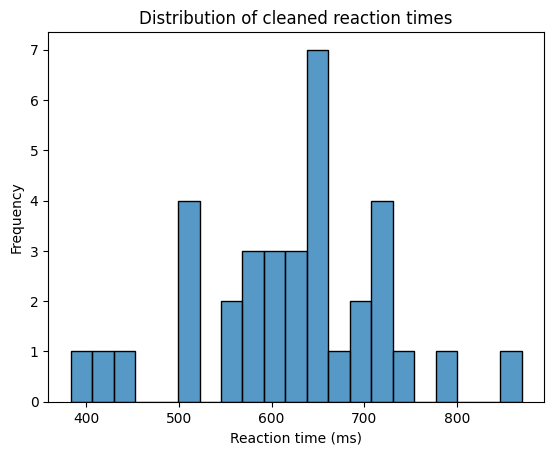

## **Visualizing psychological data**

Plots help us understand patterns that are difficult to see from numbers alone.

In psychological datasets, we often use different plots for different questions:

- **histograms** to inspect the distribution of one numerical variable;
- **boxplots** to summarize and compare distributions across groups;
- **stripplots** to show individual participants;
- **scatterplots** to study relationships between two numerical variables;
- **barplots** to summarize group means.

### <font color="orange">**Visualization of quantitative distributions**</font>

Before running statistical tests, it is useful to inspect the distribution of the variables.

Distribution plots help us understand:

- whether the values are concentrated around a typical range;
- whether the distribution is approximately symmetric or skewed;
- whether there are extreme values or possible outliers;
- whether different groups or conditions show similar or different patterns.

#### **1. Histogram**

A **histogram** is the graphical representation of a frequency distribution table.

It divides a numerical variable into intervals, called **bins**, and counts how many observations fall into each bin.

- The x-axis shows the value intervals.
- The y-axis shows the frequency of observations.
- Adjacent bars indicate that the variable is continuous.

Histograms are useful for inspecting the overall shape of a distribution.

#### **2. Density plot (KDE)**

A **density plot** shows a smoothed estimate of the distribution.

It is often overlaid on a histogram to make the overall shape easier to see.

The **Kernel Density Estimate (KDE)** does not count observations in fixed bins. Instead, it estimates a smooth curve representing where values are more or less concentrated.

#### **3. Boxplot**

A **boxplot** summarizes the distribution of a numerical variable using the median, quartiles, and possible outliers.

- The **central line** represents the median, or second quartile ($Q_2$).
- The **box edges** represent the first quartile ($Q_1$) and third quartile ($Q_3$).
- The **box** contains the central 50% of the data, also called the interquartile range (IQR).
- The **whiskers** extend to the most extreme values that are not considered outliers, usually according to the 1.5 $\times$ IQR rule.
- Individual points beyond the whiskers are shown as possible **outliers**.

Boxplots are especially useful for comparing the distribution of a variable across groups or experimental conditions.

In [ ]:
# Basic visualization settings
DIM = 15
plt.rcParams.update({'font.size': DIM, 'axes.labelsize': DIM, 'axes.titlesize': DIM,
                     'xtick.labelsize': DIM-6, 'ytick.labelsize': DIM-6, 'legend.fontsize' : DIM-3})

Text(0.5, 1.0, 'Distribution of cleaned reaction times')

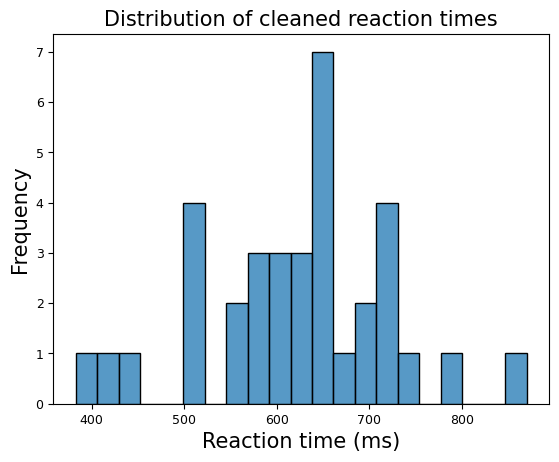

In [ ]:
# Histogram for reaction time
plt.subplots()
sns.histplot(data=data_clean, x="reaction_time_ms", bins=21)

plt.xlabel("Reaction time (ms)")
plt.ylabel("Frequency")
plt.title("Distribution of cleaned reaction times")



In [ ]:
# Plot histogram for reaction time with mean, median, Q1 and Q3

# compute metrics
RT_clean = data_clean['reaction_time_ms']

Q1 = RT_clean.quantile(0.25)
Q3 = RT_clean.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print('----- IQR -----')
print(f"Q1 (25%): {Q1:,.0f} ms")
print(f"Q3 (75%): {Q3:,.0f} ms")
print(f"IQR: {IQR:,.0f} ms")
print(f"Lower limit: {lower_limit:,.0f} ms")
print(f"Upper limit: {upper_limit:,.0f} ms")



----- IQR -----
Q1 (25%): 570 ms
Q3 (75%): 690 ms
IQR: 120 ms
Lower limit: 391 ms
Upper limit: 869 ms


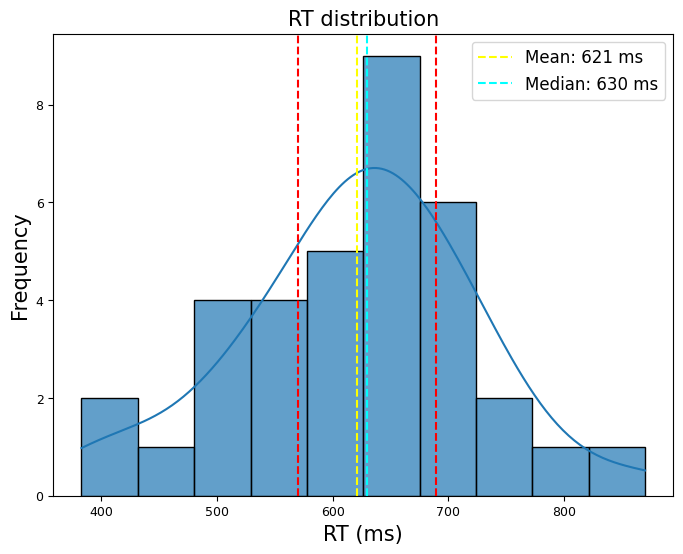

In [ ]:
# Histogram

plt.figure(figsize=(8, 6))

# plot histogram
sns.histplot(RT_clean, bins=10, kde=True, color='tab:blue', edgecolor='black', alpha=0.7)

# plot vertical lines for Q1, Q3, mean and median
plt.axvline(Q1, color='red', linestyle='--')
plt.axvline(Q3, color='red', linestyle='--')
plt.axvline(RT_clean.mean(), color='yellow', linestyle='--', label=f"Mean: {RT_clean.mean():.0f} ms")
plt.axvline(RT_clean.median(), color='cyan', linestyle='--', label=f"Median: {RT_clean.median():.0f} ms")

plt.title('RT distribution')
plt.xlabel('RT (ms)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

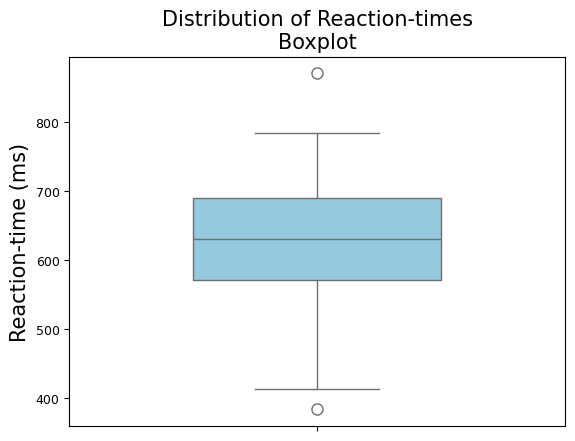

In [ ]:
# Boxplot

RT_clean = data_clean['reaction_time_ms']

fig,ax = plt.subplots()

# plot boxplot
sns.boxplot(RT_clean, ax=ax, color='skyblue', width=0.5, fliersize=8)

ax.set_title('Distribution of Reaction-times\nBoxplot')
ax.set_ylabel('Reaction-time (ms)')

#ax.axhline(median, color='tab:orange', linestyle='-', label=f'Median: {median:.0f} ms')
#ax.axhline(mean, color='magenta', linestyle='--', label=f'Mean: {mean:.0f} ms')
#ax.legend()
plt.show()

# **Correlation and Covariance**

# maybe no cov



So far, we have described one variable at a time. This is called **univariate analysis**.

We now move to **bivariate analysis**, where we study the relationship between two quantitative variables.

The main question is:

**When one variable changes, does the other variable tend to change in a systematic way?**

### <font color="orange">Covariance ($	\text{Cov}(x, y)$)</font>
The **Covariance** is a measure that indicates how two quantitative variables **vary together** relative to their respective means.

$$
	\text{Cov}(x, y) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{n-1}
$$

#### Interpretation:

* **Positive Covariance ($> 0$):** If $x$ increases, $y$ also tends to increase (and vice versa).
* **Negative Covariance ($< 0$):** If $x$ increases, $y$ tends to decrease (and vice versa).
* **Covariance Close to Zero ($\approx 0$):** There is no strong linear relationship.

#### Main Limitation:

Covariance directly depends on the **units of measurement** of the variables. This means that a value of 1000 could indicate a weak or strong relationship depending on whether the variables are measured in cents or millions. Therefore, Covariance is not useful for comparing the strength of relationships between different pairs of variables.



### <font color="orange">Pearson Correlation ($r$ or $\rho$)</font>

The **Pearson Correlation** coefficient (or product-moment correlation coefficient) is essentially the **standardized** (or normalized) Covariance. This solves the units problem and provides a pure measure of the **strength and direction** of the linear relationship.

$$
\rho = \frac{	\text{Cov}(x, y)}{s_x s_y}
$$

where $s_x$ and $s_y$ are the standard deviations of $x$ and $y$.

#### Interpretation of $\rho$:

* **Fixed Range:** The value of $\rho$ is always between **-1** and **+1**.
* **Direction (Sign):**
    * **$\rho > 0$ (Positive):** Both variables move in the same direction (e.g., study hours $\uparrow$, grade $\uparrow$).
    * **$ < 0$ (Negative):** The variables move in opposite directions (e.g., temperature $\uparrow$, coat sales $\downarrow$).
* **Strength (Magnitude):**
    * **$|| \approx 1$:** Very strong linear relationship.
    * **$|| \approx 0.5$:** Moderate linear relationship.
    * **$|| \approx 0$:** Weak or no linear relationship.


## **Research question**

Are anxiety and depression scores associated?

In this example:

- `anxiety_score` is the first quantitative variable;
- `depression_score` is the second quantitative variable.

We expect these variables to be positively correlated: participants with higher anxiety scores may also tend to have higher depression scores.

### **Plot the relationship**

Before computing the correlation, we visualize the relationship using a scatterplot.

Each point represents one participant.

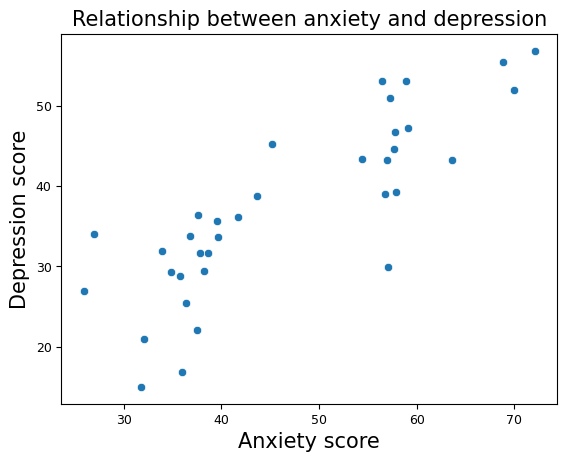

In [ ]:
# Let's plot their relationship

sns.scatterplot(data=data_clean, x="anxiety_score", y="depression_score")

plt.xlabel("Anxiety score")
plt.ylabel("Depression score")
plt.title("Relationship between anxiety and depression")
plt.show()

We can also add a regression line to make the linear trend easier to see.

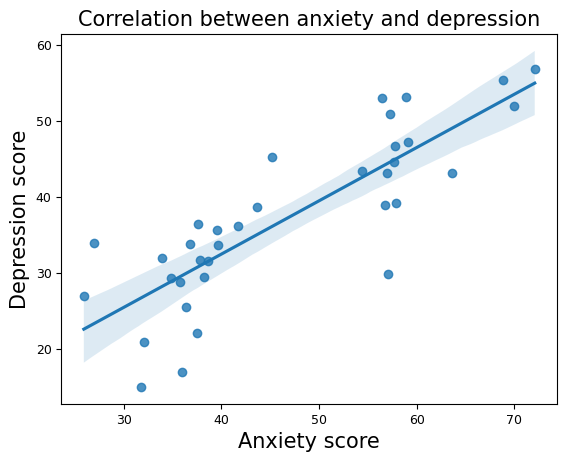

In [ ]:
# we can plot also
sns.regplot(data=data_clean, x="anxiety_score", y="depression_score")

plt.xlabel("Anxiety score")
plt.ylabel("Depression score")
plt.title("Correlation between anxiety and depression")#+fr'$\rho={round(r_value,3)} - p={p_value:.3f}$')
plt.show()

### **Compute Pearson correlation**

We now compute the Pearson correlation coefficient and its p-value.

The correlation coefficient tells us the strength and direction of the relationship.

The p-value tells us whether the observed correlation is unlikely under the null hypothesis of no linear association.

In [ ]:
# Compute the pearson correlation between the Anxiety score and the Depression score
r_value, p_value = pearsonr(data_clean["anxiety_score"], data_clean["depression_score"])

print(f"r = {r_value:.3f}")
print(f"p = {p_value:.3f}")

r = 0.833
p = 0.000


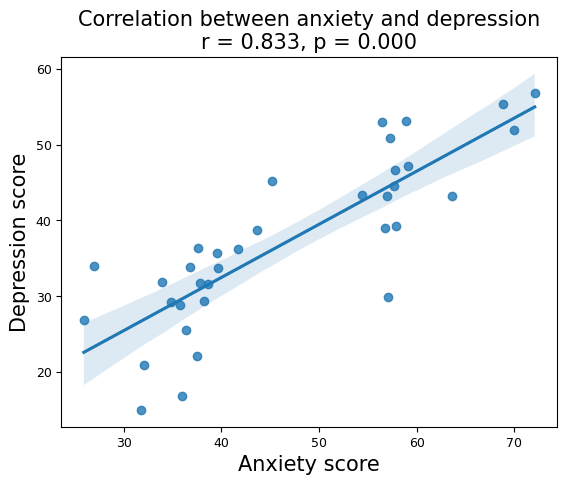

In [ ]:
sns.regplot(data=data_clean, x="anxiety_score", y="depression_score")

plt.xlabel("Anxiety score")
plt.ylabel("Depression score")
plt.title(f"Correlation between anxiety and depression\nr = {r_value:.3f}, p = {p_value:.3f}")
plt.show()

### **Interpret the correlation**

A correlation tells us **whether two variables are  associated**. <br>

- A positive correlation means that higher values of one variable tend to be associated with higher values of the other variable.
- A negative correlation means that higher values of one variable tend to be associated with lower values of the other variable.
- A correlation close to zero means that there is little or no linear relationship between the two variables.

#### **Note:**

Importantly, **correlation does not imply causation**.

Even if two variables are correlated, this does not mean that one variable causes the other.


In [ ]:
if p_value < 0.05:
    print("Anxiety and depression scores are significantly correlated.")
else:
    print("Anxiety and depression scores are not significantly correlated.")

Anxiety and depression scores are significantly correlated.


## <font color="red">**Exercise**: explore different relationships</font>

Now choose two variables and investigate their relationship.

For each pair of variables:

1. create a scatterplot;
2. add a regression line;
3. compute the Pearson correlation coefficient;
4. interpret the direction, strength, and p-value.

Try to find:

- one pair of variables with a positive correlation;
- one pair of variables with a weak or no correlation;
- one pair of variables with a negative correlation.

<br>
<i>Suggested couples of variables:

- reaction_time_ms vs accuracy
- anxiety_score vs sleep_hours
- age vs accuracy
- age vs depression_score </i>

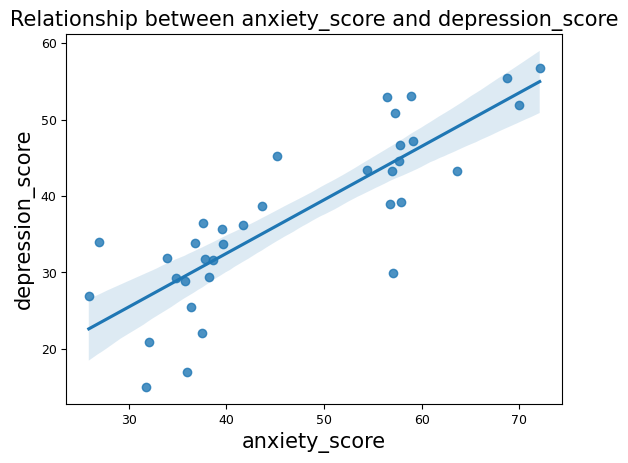

r = 0.833
p = 0.000


In [ ]:
## Template for exercise
x_variable = "anxiety_score"
y_variable = "depression_score"

sns.regplot(data=data_clean, x=x_variable, y=y_variable)

plt.xlabel(x_variable)
plt.ylabel(y_variable)
plt.title(f"Relationship between {x_variable} and {y_variable}")
plt.show()

r_value, p_value = pearsonr(data_clean[x_variable], data_clean[y_variable])

print(f"r = {r_value:.3f}")
print(f"p = {p_value:.3f}")

In [ ]:
if r_value > 0:
    print("The relationship is positive.")
elif r_value < 0:
    print("The relationship is negative.")
else:
    print("There is no linear relationship.")

if abs(r_value) > 0.7:
    print("The relationship is strong.")
elif abs(r_value) > 0.3:
    print("The relationship is moderate.")
else:
    print("The relationship is weak.")

if p_value < 0.05:
    print("The correlation is statistically significant.")
else:
    print("The correlation is not statistically significant.")

The relationship is positive.
The relationship is strong.
The correlation is statistically significant.


### **Correlation matrix and heatmap**

When we have several numerical variables, it is useful to summarize all pairwise correlations in a **correlation matrix**.

A correlation matrix shows the Pearson correlation coefficient between each pair of variables.

A **heatmap** is a visual representation of this matrix:

- each cell represents the correlation between two variables;
- the color indicates the strength and direction of the correlation;
- positive correlations and negative correlations are shown with different colors.

This is useful for quickly exploring patterns in a psychological dataset and identifying which variables may be related.

In [ ]:
correlation_matrix = data_clean[numerical_variables].corr()

correlation_matrix

,age,anxiety_score,depression_score,perceived_stress,sleep_hours,accuracy,reaction_time_ms
age,1.000000,-0.160091,-0.097765,-0.043874,0.253720,0.111379,-0.070118
anxiety_score,-0.160091,1.000000,0.832735,0.769553,0.022691,-0.067842,0.144808
depression_score,-0.097765,0.832735,1.000000,0.692693,0.109434,-0.110702,0.171687
perceived_stress,-0.043874,0.769553,0.692693,1.000000,-0.147152,0.085547,-0.116289
sleep_hours,0.253720,0.022691,0.109434,-0.147152,1.000000,0.174955,0.056553
accuracy,0.111379,-0.067842,-0.110702,0.085547,0.174955,1.000000,-0.758443
reaction_time_ms,-0.070118,0.144808,0.171687,-0.116289,0.056553,-0.758443,1.000000


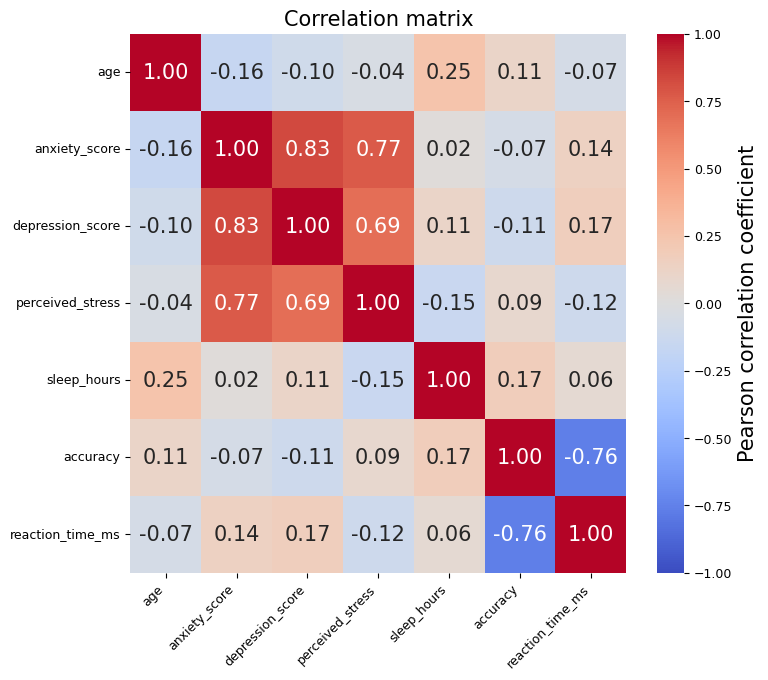

In [ ]:
plt.figure(figsize=(8, 7))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, cbar_kws={"label": "Pearson correlation coefficient"})

plt.title("Correlation matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

### **How to read the heatmap**

Each cell of the heatmap contains a Pearson correlation coefficient.

- Values close to **+1** indicate a strong positive relationship.
- Values close to **-1** indicate a strong negative relationship.
- Values close to **0** indicate a weak or no linear relationship.

The diagonal is always equal to 1 because each variable is perfectly correlated with itself.

The heatmap helps us identify broad patterns before looking more closely at specific pairs of variables.

### **<font color="teal">Optional: p-values and multiple comparisons</font>**

The heatmap shows the correlation coefficient for each pair of variables.

However, if we want to know which correlations are statistically significant, we also need a p-value for each correlation.

Because we test many pairs of variables at the same time, we should correct for multiple comparisons. Otherwise, some correlations may appear significant just by chance.

Here, we use the Bonferroni correction, which is simple and conservative.

In [ ]:
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

In [ ]:
X = data_clean[numerical_variables]
variables = X.columns
n_variables = len(variables)

p_values = []
pairs = []

for i in range(n_variables):
    for j in range(i + 1, n_variables):
        valid_data = X[[variables[i], variables[j]]].dropna()
        r_value, p_value = pearsonr(valid_data[variables[i]], valid_data[variables[j]])
        pairs.append((variables[i], variables[j], r_value, p_value))
        p_values.append(p_value)

#### Bonferroni correction

In [ ]:
reject, corrected_p_values, _, _ = multipletests(p_values, alpha=0.05, method="bonferroni")

In [ ]:
correlation_results = pd.DataFrame(pairs, columns=["Variable 1", "Variable 2", "r", "p uncorrected"])
correlation_results["p corrected"] = corrected_p_values
correlation_results["Significant after correction"] = reject

correlation_results.sort_values("p corrected")

,Variable 1,Variable 2,r,p uncorrected,p corrected,Significant after correction
6,anxiety_score,depression_score,0.832735,5.506573e-10,1.156380e-08,True
7,anxiety_score,perceived_stress,0.769553,6.563435e-08,1.378321e-06,True
20,accuracy,reaction_time_ms,-0.758443,1.303663e-07,2.737693e-06,True
11,depression_score,perceived_stress,0.692693,4.006385e-06,8.413408e-05,True
3,age,sleep_hours,0.253720,1.413718e-01,1.000000e+00,False
2,age,perceived_stress,-0.043874,8.023877e-01,1.000000e+00,False
5,age,reaction_time_ms,-0.070118,6.889730e-01,1.000000e+00,False
0,age,anxiety_score,-0.160091,3.582748e-01,1.000000e+00,False
4,age,accuracy,0.111379,5.241367e-01,1.000000e+00,False
8,anxiety_score,sleep_hours,0.022691,8.970529e-01,1.000000e+00,False


Bonferroni correction controls false positives by making the significance threshold more strict. It is simple but conservative.

#### False discovery rate

FDR correction controls the expected proportion of false discoveries among significant results. It is less conservative and often used in exploratory analyses.

In [ ]:
reject, corrected_p_values, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

In [ ]:
significance_matrix = pd.DataFrame("", index=variables, columns=variables)

for _, row in correlation_results.iterrows():
    if row["Significant after correction"]:
        significance_matrix.loc[row["Variable 1"], row["Variable 2"]] = "*"
        significance_matrix.loc[row["Variable 2"], row["Variable 1"]] = "*"

significance_matrix

,age,anxiety_score,depression_score,perceived_stress,sleep_hours,accuracy,reaction_time_ms
age,,,,,,,
anxiety_score,,,*,*,,,
depression_score,,*,,*,,,
perceived_stress,,*,*,,,,
sleep_hours,,,,,,,
accuracy,,,,,,,*
reaction_time_ms,,,,,,*,


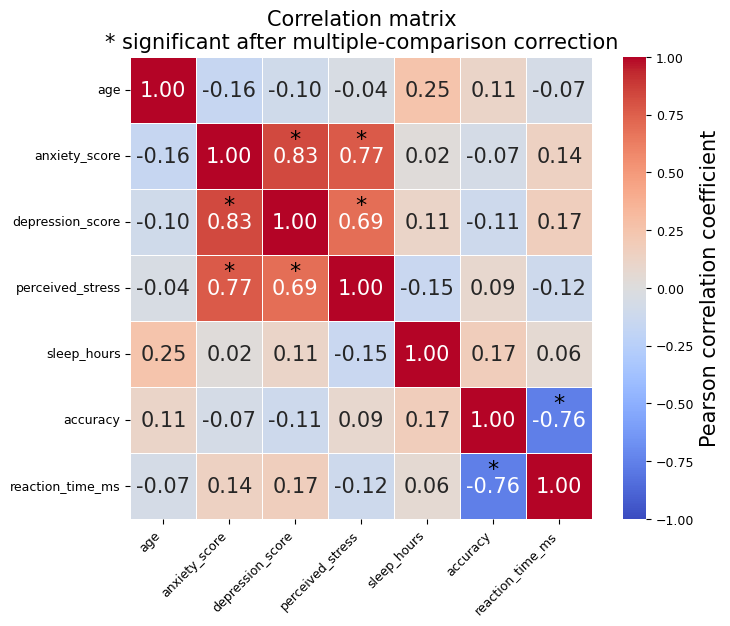

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={"label": "Pearson correlation coefficient"})

for y, variable_y in enumerate(variables):
    for x, variable_x in enumerate(variables):
        if significance_matrix.loc[variable_y, variable_x] == "*":
            plt.text(x + 0.5, y + 0.25, "*", ha="center", va="center", color="black", fontsize=16)

plt.title("Correlation matrix\n* significant after multiple-comparison correction")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

# **t-test**



## **<font color="orange">Independent-samples t-test</font>**

A t-test is used when we want to compare the mean of a numerical variable between two groups.

In this example, we ask:

### **Do clinical participants have higher anxiety scores than control participants?**

Here:

- the numerical variable is `anxiety_score`;
- the grouping variable is `group`;
- the two groups are `control` and `clinical`.

The t-test compares the average anxiety score in the two groups and evaluates whether the observed difference is larger than what we would expect from random variation alone.



## One samle t-test (example Giada/Ana lesson)


### Extract the two groups

First, we split the data into the two groups we want to compare.

In [ ]:
control_anxiety = data_clean[data_clean["group"] == "control"]["anxiety_score"]
clinical_anxiety = data_clean[data_clean["group"] == "clinical"]["anxiety_score"]

In [ ]:
control_anxiety.mean(), clinical_anxiety.mean()

(np.float64(36.4388888888889), np.float64(57.576470588235296))

#### Data visualization: compare the 2 groups

With **small samples**, normality tests can be unstable. <br>

For this reason, it is also useful to inspect the data visually, for example using histograms or boxplots.


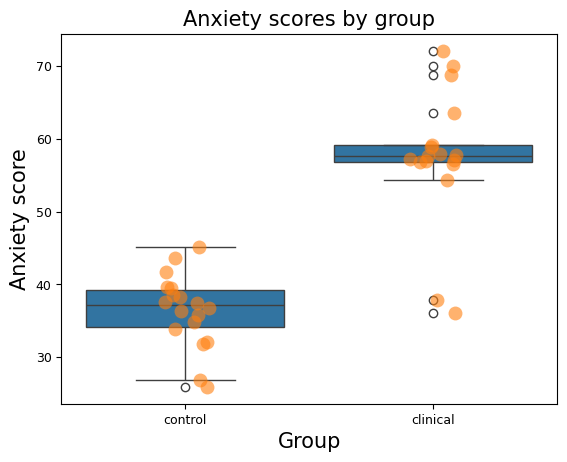

In [ ]:
sns.boxplot(data=data_clean, x="group", y="anxiety_score", color='tab:blue')
sns.stripplot(data=data_clean, x="group", y="anxiety_score", size=10, alpha=0.6, color='tab:orange')

plt.xlabel("Group")
plt.ylabel("Anxiety score")
plt.title("Anxiety scores by group")
plt.show()

### Check assumptions for t-test

Before running the t-test, we check whether the main assumptions are reasonable.

For an independent-samples t-test, we assume that:

1. observations are **independent**;
2. the variable is approximately **normally distributed** within each group;
3. the two groups have **similar variances**.

In real psychological data, these assumptions are often approximate rather than perfect. The goal is to check whether there are strong violations.

#### 2. Approximate normality: Shapiro-Wilk test

The **Shapiro-Wilk test** checks whether the distribution strongly deviates from normality.

A p-value larger than 0.05 suggests that there is no strong evidence against normality.  
A p-value smaller than 0.05 suggests that the distribution may deviate from normality.

In [ ]:
statistic, p_value = shapiro(control_anxiety)
print(f"Control group: W = {statistic:.3f}, p = {p_value:.3f}")

statistic, p_value = shapiro(clinical_anxiety)
print(f"Clinical group: W = {statistic:.3f}, p = {p_value:.3f}")

Control group: W = 0.963, p = 0.665
Clinical group: W = 0.834, p = 0.006


#### 3. Similarity between variances: Levene test

Levene’s test checks whether the two groups have similar variances.

A p-value larger than 0.05 suggests that the equal-variance assumption is reasonable.  
A p-value smaller than 0.05 suggests that the variances differ between groups.

- If Levene’s test is not significant, the equal-variance assumption is reasonable.
- If it is significant, we can use Welch’s t-test.

In [ ]:
statistic, p_value = levene(control_anxiety, clinical_anxiety)
print(f"Levene test: W = {statistic:.3f}, p = {p_value:.3f}")

Levene test: W = 0.957, p = 0.335


#### 3.2 Welch’s t-test

If the two groups have different variances, or if we are not sure that the variances are equal, we can use Welch’s t-test.

Welch’s t-test compares the two group means without assuming equal variances, so it is often a safer default choice.



### Run the t-test

In this simulated dataset, we expect the clinical group to show higher anxiety scores than the control group, because the data were generated to mimic a realistic difference between groups.

In [ ]:
t_statistic, p_value = ttest_ind(control_anxiety, clinical_anxiety, equal_var=True)

print(f"t = {t_statistic:.3f}")
print(f"p = {p_value:.5f}")

t = -8.374
p = 0.00000


We now run Welch’s independent-samples t-test to compare anxiety scores between the control and clinical groups.

We use Welch’s version because it does not assume that the two groups have exactly the same variance. This makes it a good default choice for many real datasets.

The test returns two main values:

- `t_statistic`: the size of the group difference relative to the variability in the data;
- `p_value`: the probability of observing a difference this large, or larger, if there were actually no difference between the groups.


In [ ]:
# `equal_var=False` :  Welch's t-test
t_statistic, p_value = ttest_ind(control_anxiety, clinical_anxiety, equal_var=False)

print(f"Welch's t-test: t = {t_statistic:.3f}, p = {p_value:.3f}")

Welch's t-test: t = -8.240, p = 0.000


### **Interpret the result**

We compare the p-value with the conventional significance threshold of 0.05.

If `p < 0.05`, we conclude that the two groups differ significantly in their average anxiety score.

If `p >= 0.05`, we do not have enough evidence to conclude that the two groups differ.

Remember: a significant result means that the group averages differ more than expected by chance. It does not mean that all participants in one group have higher scores than all participants in the other group.



In [ ]:
if p_value < 0.05:
    print("The two groups differ significantly in anxiety scores.")
else:
    print("The two groups do not differ significantly in anxiety scores.")

The two groups differ significantly in anxiety scores.



In this example, the t-test addresses a psychological question:
**whether participants in the clinical group report higher anxiety than participants in the control group.**

The statistical test helps us decide **whether the observed difference in the sample is large enough to be considered unlikely under the null hypothesis of no group difference**.

# ANOVA

### **<font color="orange">Compare more than two conditions: one-way ANOVA</font>**

A one-way ANOVA is used when we want to compare the mean of a numerical variable across more than two groups or conditions.

Here, we ask:

**Do reaction times differ across experimental conditions?**

In this dataset:

- the numerical variable is `reaction_time_ms`;
- the grouping variable is `condition`;
- the three conditions are `neutral`, `social_evaluation`, and `time_pressure`.

The ANOVA tests whether at least one condition has a different mean reaction time from the others.

Importantly, ANOVA does not immediately tell us which specific conditions differ from each other. It only tells us whether there is evidence for a difference somewhere among the condition means.

In [ ]:
data_clean["condition"].value_counts()

,count
condition,
neutral,13
social_evaluation,11
time_pressure,11


### **Extract the reaction times for each condition**

Before running the ANOVA, we separate the reaction-time values according to the experimental condition.

This gives us three groups of values:

- reaction times in the `neutral` condition;
- reaction times in the `social_evaluation` condition;
- reaction times in the `time_pressure` condition.

The ANOVA will compare the mean reaction time across these three conditions.

In [ ]:
neutral_rt           = data_clean[data_clean["condition"] == "neutral"]["reaction_time_ms"]
social_evaluation_rt = data_clean[data_clean["condition"] == "social_evaluation"]["reaction_time_ms"]
time_pressure_rt     = data_clean[data_clean["condition"] == "time_pressure"]["reaction_time_ms"]

In [ ]:
print(f"Neutral: n = {len(neutral_rt)}")
print(f"Social evaluation: n = {len(social_evaluation_rt)}")
print(f"Time pressure: n = {len(time_pressure_rt)}")

Neutral: n = 13
Social evaluation: n = 11
Time pressure: n = 11


### Visualizing reaction-times by condition

Text(0.5, 1.0, 'Reaction times by experimental condition')

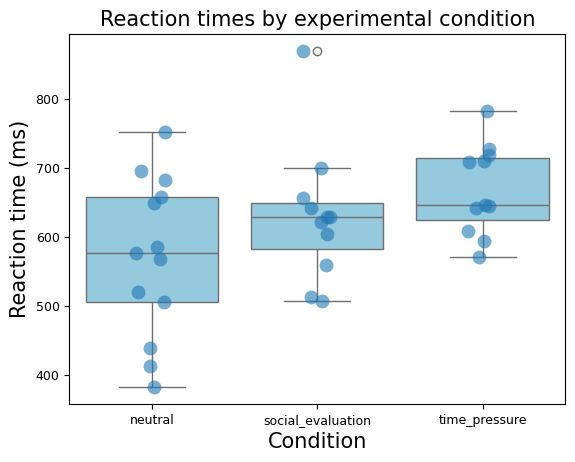

In [ ]:
sns.boxplot(data=data_clean, x="condition", y="reaction_time_ms", color='skyblue')
sns.stripplot(data=data_clean, x="condition", y="reaction_time_ms", size=10, alpha=0.6)

plt.xlabel("Condition")
plt.ylabel("Reaction time (ms)")
plt.title("Reaction times by experimental condition")


Text(0.5, 1.0, 'Mean reaction time by condition')

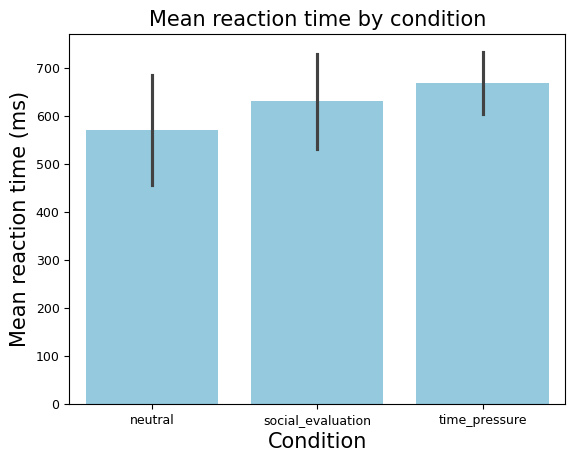

In [ ]:
# Barplot: mean and std by condition
sns.barplot(data=data_clean, x="condition", y="reaction_time_ms", errorbar="sd", color='skyblue')

plt.xlabel("Condition")
plt.ylabel("Mean reaction time (ms)")
plt.title("Mean reaction time by condition")


### **Check ANOVA assumptions**

Before running a one-way ANOVA, we check whether its main assumptions are reasonable.

The main assumptions are:

1. **Independence**: observations should be independent from each other.
2. **Approximate normality**: reaction times should be approximately normally distributed within each condition.
3. **Homogeneity of variance**: the variability of reaction times should be similar across conditions.

In real psychological data, these assumptions are **rarely** perfect.

The goal is to check whether there are strong violations that would make the ANOVA inappropriate.

#### 2. Approximate normality in each condition

We use the Shapiro-Wilk test to check whether reaction times strongly deviate from normality within each condition.

A p-value larger than 0.05 suggests that there is no strong evidence against normality.  
A p-value smaller than 0.05 suggests that the distribution may deviate from normality.

With small samples, this test should be interpreted cautiously, so it is also useful to inspect the data visually.

In [ ]:
for condition in data_clean["condition"].unique():
    values = data_clean[data_clean["condition"] == condition]["reaction_time_ms"]
    statistic, p_value = shapiro(values)
    print(f"{condition}: W = {statistic:.3f}, p = {p_value:.3f}")

neutral: W = 0.963, p = 0.803
social_evaluation: W = 0.878, p = 0.098
time_pressure: W = 0.951, p = 0.663


#### 3. Similar variances: Levene test

We use Levene’s test to check whether the three conditions have similar variances.

A p-value larger than 0.05 suggests that the equal-variance assumption is reasonable.  
A p-value smaller than 0.05 suggests that the variability differs across conditions.

In [ ]:
statistic, p_value = levene(neutral_rt, social_evaluation_rt, time_pressure_rt)
print(f"Levene test: W = {statistic:.3f}, p = {p_value:.3f}")

Levene test: W = 1.297, p = 0.287


### **Run the one-way ANOVA**

We now run a one-way ANOVA to test whether mean reaction time differs across the three experimental conditions.

The ANOVA returns two main values:

- `f_statistic`: the ratio between variability explained by the condition and unexplained variability within conditions;
- `p_value`: the probability of observing an effect this large, or larger, if there were actually no difference between the condition means.

If the p-value is below 0.05, we conclude that reaction times differ significantly across conditions.

In [ ]:
f_statistic, p_value = f_oneway(neutral_rt, social_evaluation_rt, time_pressure_rt)

print(f"F = {f_statistic:.3f}")
print(f"p = {p_value:.3f}")

F = 3.107
p = 0.058


### **Interpret the ANOVA result**

ANOVA tells us whether at least one condition differs from the others, but it does not tell us which specific conditions differ.

We compare the p-value with the conventional significance threshold of 0.05.

If `p < 0.05`, we conclude that at least one experimental condition has a different mean reaction time from the others.

If `p >= 0.05`, we do not have enough evidence to conclude that reaction times differ across conditions.

Importantly, a significant ANOVA does not tell us which specific conditions differ. It only tells us that there is evidence for a difference somewhere among the condition means.

In [ ]:
if p_value < 0.05:
    print("Reaction times differ significantly across conditions.")
else:
    print("Reaction times do not differ significantly across conditions.")

Reaction times do not differ significantly across conditions.


In this simulated dataset, we expect reaction times to be slower in more demanding conditions, especially during `time_pressure` and `social_evaluation`, because these conditions were designed to mimic increased cognitive or emotional demand.

# Summary

In this notebook, we analyzed a small psychological dataset.

We learned how to:

Inspect the data:
- inspect the structure of a dataset;
- identify numerical and categorical variables;

Filter the data:
- detect missing values;
- remove missing and implausible observations;

Analyze some statistics:
- compute descriptive statistics;
- study the association between two variables using correlation;
- compare two groups using a t-test;
- compare more than two conditions using ANOVA;

Plotting results:
- visualize data using histograms, scatterplots, boxplots and barplots;

The same workflow can be applied to many psychological datasets, including questionnaire data, behavioral experiments, clinical assessments and social psychology studies.